##Google CoLab Instructions


In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
!nvidia-smi

GPU Available: True
Tue Jul 29 13:02:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [ ]:
import google.colab
from google.colab import drive
drive.mount('/mnt/drive', force_remount=True)
try:
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import torch
has_mps = torch.backends.mps.is_built()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Mounted at /mnt/drive
Note: using Google CoLab
Using device: cuda:0



##Detecting Faces in an Image

In [ ]:
!pip uninstall -y torch torchvision
!pip install torch torchvision --no-cache-dir


Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 284.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 221.1 MB/s eta 0:00:00


In [ ]:
!pip install facenet-pytorch


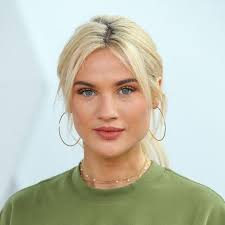

In [ ]:
from facenet_pytorch import MTCNN
from PIL import Image
import requests
from io import BytesIO
from PIL import Image, ImageDraw

# Load image
#url = "https://data.heatonresearch.com/images/wustl/data/AdobeStock_319245189-low.jpg"
image_path= "/mnt/drive/MyDrive/final project/dataset/download (3).jpg"
img = Image.open(image_path).convert('RGB')
img.load()
img

In [ ]:
mtcnn = MTCNN(keep_all=True, device=device)

In [ ]:

class NestedImageDataset(Dataset):
    def __init__(self, root_dir=None, images=None, labels=None, class_names=None, transform=None):


        if root_dir:
                self.images = []
                self.labels = []
                self.class_names = sorted(os.listdir(root_dir))  # Get class folder names, sorted for consistency
                self.transform = transform

                for label_index, class_name in enumerate(self.class_names):
                    class_path = os.path.join(root_dir, class_name)

                    # This walks through all subfolders and files inside the class directory
                    for subdir, _, files in os.walk(class_path):
                        for file in files:
                            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                                file_path = os.path.join(subdir, file)
                                self.images.append(file_path)       # Store full path to image
                                self.labels.append(label_index)     # Store corresponding label index
      # Store full path to image
        elif images!= None and labels!=None :
            self.images = images
            self.labels = labels
            self.class_names = class_names
            self.transform = transform
        else:
            raise ValueError("Either root_dir or images and labels must be provided.")

    def __len__(self):
        return len(self.images)  # Total number of images in the dataset

    def __getitem__(self, idx):
           # Check if self.images contains file paths or PIL Image objects
        if isinstance(self.images[idx], str):  # If it's a file path
            image = Image.open(self.images[idx]).convert('RGB')
        else:  # If it's already a PIL Image object
            image = self.images[idx].convert('RGB')  # Just convert to RGB

        img_path = self.images[idx]
        label = self.labels[idx]


        if self.transform:
            image = self.transform(image)

        return image, label


    def get_subset_n_per_class(self, n, seed=42):
            random.seed(seed)
            class_to_indices = defaultdict(list)

            # Group indices by class
            for idx, (_, label) in enumerate(self):
                class_to_indices[label].append(idx)

            # Select n samples per class
            selected_indices = []
            for label, indices in class_to_indices.items():
                if len(indices) < n:
                    raise ValueError(f"Class {label} has only {len(indices)} samples, less than {n}")
                selected_indices.extend(random.sample(indices, n))

            return Subset(self, selected_indices)
    def count_images_per_class(self):
        count_dict = Counter(self.labels)  # self.targets is a list of class indices
        for class_idx, class_name in enumerate(self.class_names):
            count = count_dict.get(class_idx, 0)
            print(f"{class_name}: {count} images")


In [ ]:
def detect_faces(img):
    try:
        boxes, _ = mtcnn.detect(img)  # <-- Correct usage

        if boxes is None or len(boxes) == 0:
            return None

        # Crop the first face (you can change this if you want multiple faces)
        x1, y1, x2, y2 = map(int, boxes[0])
        cropped_face = img.crop((x1, y1, x2, y2))
        return cropped_face

    except Exception as e:
        print(f"Detection error: {e}")
        return None

    except Exception as e:
        print(f"Error in face detection: {e}")
        return None

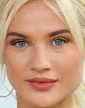

In [ ]:
cropped_face = detect_faces(img)
cropped_face

In [ ]:

dataset_root ='/mnt/drive/MyDrive/final project/dataset/6_classes'
print(dataset_root)
dataset = NestedImageDataset(root_dir=dataset_root)
face_images=[]
images = dataset.images
print(len(images))

# Output folder in your Google Drive
output_folder = '/mnt/drive/MyDrive/cropped_faces'
os.makedirs(output_folder, exist_ok=True)
labels_dic = {}
labels_name= dataset.class_names
# Loop through each class folder
for label in os.listdir(dataset_root):
    class_dir = os.path.join(dataset_root, label)
    if not os.path.isdir(class_dir):
        continue
labels_i = dataset.labels

for label in labels_i:
    labels_dic[label] = labels_name[label]


/mnt/drive/MyDrive/final project/dataset/6_classes
2825


In [ ]:
labels_dic

{0: 'CompleteFlaccid',
 1: 'MildFlaccid',
 2: 'ModerateFlaccid',
 3: 'NearNormalFlaccid',
 4: 'Normal',
 5: 'SevereFlaccid'}

In [ ]:

face_images=[]
images = dataset.images
print(len(images))

def process_image(img_path):
    try:
        img = Image.open(img_path).convert('RGB')  # Ensure it is in RGB format
        face = detect_faces(img)  # Detect faces
        if face is not None:
            face_images.append(face)
        else:
            print(f"No face detected in {img_path}")
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

# Use TQDM to track the progress and ThreadPoolExecutor for parallel processing
with ThreadPoolExecutor(max_workers=4) as executor:
    # Wrapping in tqdm to get a progress bar
    for _ in tqdm(executor.map(process_image, images), total=len(images), desc="Processing Images"):
      if len(face_images) % 100 == 0:
        print(f"Detected {len(face_images)} faces so far.")
      pass

# Check if any faces were detected
if face_images:
    print(f"Total faces found: {len(face_images)}")
else:
    print("No faces were detected.")

2825


Processing Images:   4%|▎         | 99/2825 [00:19<10:11,  4.46it/s]

Detected 100 faces so far.


Processing Images:   7%|▋         | 200/2825 [01:21<05:43,  7.65it/s]

Detected 200 faces so far.


...

Detected 2700 faces so far.


Processing Images:  99%|█████████▉| 2808/2825 [09:56<00:03,  4.39it/s]

Detected 2800 faces so far.
Detected 2800 faces so far.


Processing Images: 100%|██████████| 2825/2825 [09:58<00:00,  4.72it/s]

Total faces found: 2816


In [ ]:
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

save_dir = '/content/drive/MyDrive/faces_array/'
complate = '/content/drive/MyDrive/faces_array/CompleteFlaccid'
mild = '/content/drive/MyDrive/faces_array/MildFlaccid'
ModerateFlaccid = '/content/drive/MyDrive/faces_array/ModerateFlaccid'
NearNormalFlaccid= '/content/drive/MyDrive/faces_array/NearNormalFlaccid'
NormalFlaccid= '/content/drive/MyDrive/faces_array/NormalFlaccid'
SevereFlaccid= '/content/drive/MyDrive/faces_array/SevereFlaccid'
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)
os.makedirs(complate, exist_ok=True)
os.makedirs(mild, exist_ok=True)
os.makedirs(ModerateFlaccid, exist_ok=True)
os.makedirs(NearNormalFlaccid, exist_ok=True)
os.makedirs(NormalFlaccid, exist_ok=True)
os.makedirs(SevereFlaccid, exist_ok=True)

def save_image(i, img):

    filename = os.path.join(save_dir, f'image_{i:04d}.png')
    if labels_i[i] == 0:
        filename = os.path.join(complate, f'image_{i:04d}.png')
    if labels_i[i] == 1:
        filename = os.path.join(mild, f'image_{i:04d}.png')
    if labels_i[i] == 2:
        filename = os.path.join(ModerateFlaccid, f'image_{i:04d}.png')
    if labels_i[i] == 3:
        filename = os.path.join(NearNormalFlaccid, f'image_{i:04d}.png')
    if labels_i[i] == 4:
        filename = os.path.join(NormalFlaccid, f'image_{i:04d}.png')
    if labels_i[i] == 5:
        filename = os.path.join(SevereFlaccid, f'image_{i:04d}.png')
    img.save(filename)
    return i

# Limit threads to avoid Colab overload
num_threads = min(8, os.cpu_count() * 2)

with ThreadPoolExecutor(max_workers=num_threads) as executor:
    futures = [executor.submit(save_image, i, img) for i, img in enumerate(face_images)]

    for f in as_completed(futures):
        i = f.result()
        if i % 100 == 0:
            print(f'✅ Saved image {i}')


✅ Saved image 0
✅ Saved image 100
✅ Saved image 200
✅ Saved image 300
✅ Saved image 400
✅ Saved image 500
✅ Saved image 600
✅ Saved image 700
✅ Saved image 800
✅ Saved image 900
✅ Saved image 1000
✅ Saved image 1100
✅ Saved image 1200
✅ Saved image 1300
✅ Saved image 1400
✅ Saved image 1500
✅ Saved image 1600
✅ Saved image 1700
✅ Saved image 1800
✅ Saved image 1900
✅ Saved image 2000
✅ Saved image 2100
✅ Saved image 2200
✅ Saved image 2300
✅ Saved image 2400
✅ Saved image 2500
✅ Saved image 2600
✅ Saved image 2700
✅ Saved image 2800


In [ ]:
!mv /content/drive/MyDrive/faces_array/ /mnt/drive/MyDrive/


^C


In [ ]:
from concurrent.futures import ThreadPoolExecutor
load_dir= '/content/drive/MyDrive/faces_array'

def load_single_image(fname):
    img_path = os.path.join(load_dir, fname)
    return img_path

filenames = sorted(os.listdir(load_dir))  # sorted to preserve order

with ThreadPoolExecutor() as executor:
    loaded_images = list(executor.map(load_single_image, filenames))





In [ ]:
loaded_images

['/content/drive/MyDrive/faces_array/image_0000.png',
 '/content/drive/MyDrive/faces_array/image_0001.png',
 '/content/drive/MyDrive/faces_array/image_0002.png',
 '/content/drive/MyDrive/faces_array/image_0003.png',
 '/content/drive/MyDrive/faces_array/image_0004.png',
 '/content/drive/MyDrive/faces_array/image_0005.png',
 '/content/drive/MyDrive/faces_array/image_0006.png',
 '/content/drive/MyDrive/faces_array/image_0007.png',
 '/content/drive/MyDrive/faces_array/image_0008.png',
 '/content/drive/MyDrive/faces_array/image_0009.png',
 '/content/drive/MyDrive/faces_array/image_0010.png',
 '/content/drive/MyDrive/faces_array/image_0011.png',
 '/content/drive/MyDrive/faces_array/image_0012.png',
 '/content/drive/MyDrive/faces_array/image_0013.png',
 '/content/drive/MyDrive/faces_array/image_0014.png',
 '/content/drive/MyDrive/faces_array/image_0015.png',
 '/content/drive/MyDrive/faces_array/image_0016.png',
 '/content/drive/MyDrive/faces_array/image_0017.png',
 '/content/drive/MyDrive/fac

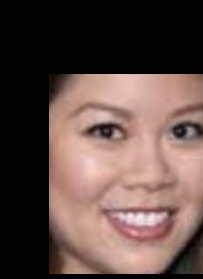

In [ ]:
Image.open(loaded_images[2556])


In [ ]:
face_dataset = NestedImageDataset(images=loaded_images, labels=labels_i, class_names=dataset.class_names)

## face split

In [ ]:
from PIL import Image

def split_face(cropped_face_path):
    # Open the image and ensure RGB
    cropped_face = Image.open(cropped_face_path).convert("RGB")

    # Get the size
    width, height = cropped_face.size
    middle = height // 2

    # Split upper and lower parts
    upper_part = cropped_face.crop((0, 0, width, middle))
    lower_part = cropped_face.crop((0, middle, width, height))

    return upper_part, lower_part  # both already RGB


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


upper_part,lower_part = split_face(cropped_face)
# Create a figure to hold the images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Show the first image
axes[0].imshow(upper_part)
axes[0].axis('off')  # Hide axis for a cleaner view

# Show the second image
axes[1].imshow(lower_part)
axes[1].axis('off')  # Hide axis for a cleaner view

plt.show()


In [ ]:
upper_dir = '/mnt/drive/MyDrive/upper_face/'
upper_complate = '/mnt/drive/MyDrive/upper_face/CompleteFlaccid'
upper_mild = '/mnt/drive/MyDrive/upper_face/MildFlaccid'
upper_ModerateFlaccid = '/mnt/drive/MyDrive/upper_face/ModerateFlaccid'
upper_NearNormalFlaccid= '/mnt/drive/MyDrive/upper_face/NearNormalFlaccid'
upper_NormalFlaccid= '/mnt/drive/MyDrive/upper_face/NormalFlaccid'
upper_SevereFlaccid= '/mnt/drive/MyDrive/upper_face/SevereFlaccid'
# Create the directory if it doesn't exist
os.makedirs(upper_dir, exist_ok=True)
os.makedirs(upper_complate, exist_ok=True)
os.makedirs(upper_mild, exist_ok=True)
os.makedirs(upper_ModerateFlaccid, exist_ok=True)
os.makedirs(upper_NearNormalFlaccid, exist_ok=True)
os.makedirs(upper_NormalFlaccid, exist_ok=True)
os.makedirs(upper_SevereFlaccid, exist_ok=True)



In [ ]:
lower_dir = '/mnt/drive/MyDrive/lower_face/'
lower_complate= '/mnt/drive/MyDrive/lower_face/CompleteFlaccid'
lower_mild = '/mnt/drive/MyDrive/lower_face/MildFlaccid'
lower_ModerateFlaccid = '/mnt/drive/MyDrive/lower_face/ModerateFlaccid'
lower_NearNormalFlaccid= '/mnt/drive/MyDrive/lower_face/NearNormalFlaccid'
lower_NormalFlaccid= '/mnt/drive/MyDrive/lower_face/NormalFlaccid'
lower_SevereFlaccid= '/mnt/drive/MyDrive/lower_face/SevereFlaccid'
# Create the directory if it doesn't exist
os.makedirs(lower_dir, exist_ok=True)
os.makedirs(lower_complate, exist_ok=True)
os.makedirs(lower_mild, exist_ok=True)
os.makedirs(lower_ModerateFlaccid, exist_ok=True)
os.makedirs(lower_NearNormalFlaccid, exist_ok=True)
os.makedirs(lower_NormalFlaccid, exist_ok=True)
os.makedirs(lower_SevereFlaccid, exist_ok=True)


In [ ]:
def call_split_face(i,img_path):
        upper_part,lower_part = split_face(img_path)  # Detect faces
        lower_filename = os.path.join(lower_dir, f'image_{i:04d}.png')
        upper_filename = os.path.join(upper_dir, f'image_{i:04d}.png')
        if labels_i[i] == 0:
            lower_filename = os.path.join(lower_complate, f'image_{i:04d}.png')
            upper_filename = os.path.join(upper_complate, f'image_{i:04d}.png')
        if labels_i[i] == 1:
            lower_filename = os.path.join(lower_mild, f'image_{i:04d}.png')
            upper_filename = os.path.join(upper_mild, f'image_{i:04d}.png')
        if labels_i[i] == 2:
            lower_filename = os.path.join(lower_ModerateFlaccid, f'image_{i:04d}.png')
            upper_filename = os.path.join(upper_ModerateFlaccid, f'image_{i:04d}.png')
        if labels_i[i] == 3:
            lower_filename = os.path.join(lower_NearNormalFlaccid, f'image_{i:04d}.png')
            upper_filename = os.path.join(upper_NearNormalFlaccid, f'image_{i:04d}.png')
        if labels_i[i] == 4:
            lower_filename = os.path.join(lower_NormalFlaccid, f'image_{i:04d}.png')
            upper_filename = os.path.join(upper_NormalFlaccid, f'image_{i:04d}.png')
        if labels_i[i] == 5:
            lower_filename = os.path.join(lower_SevereFlaccid, f'image_{i:04d}.png')
            upper_filename = os.path.join(upper_SevereFlaccid, f'image_{i:04d}.png')
        upper_part.save(upper_filename)
        lower_part.save(lower_filename)
        return i  # important for progress tracking


In [ ]:
loaded_dataset=NestedImageDataset(root_dir='/mnt/drive/MyDrive/faces_array',transform=None)

In [ ]:
loaded_dataset.images

['/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0001.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0002.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0003.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0004.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0000.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0008.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0011.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0010.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0005.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0006.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0007.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0009.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0012.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0018.png',
 '/mnt/drive/MyDrive/faces_array/CompleteFlaccid/image_0015.png',
 '/mnt/dri

In [ ]:
for i in : print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
# Limit threads to avoid Colab overload
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

num_threads = min(8, os.cpu_count() * 2)

with ThreadPoolExecutor(max_workers=num_threads) as executor:
    futures = [executor.submit(call_split_face, i, img) for i, img in enumerate()]
    for f in as_completed(futures):
        i = f.result()
        if i % 100 == 0:
            print(f'✅ Saved image {i}')


In [ ]:
print(len(lower_parts),len(upper_parts))


800 800


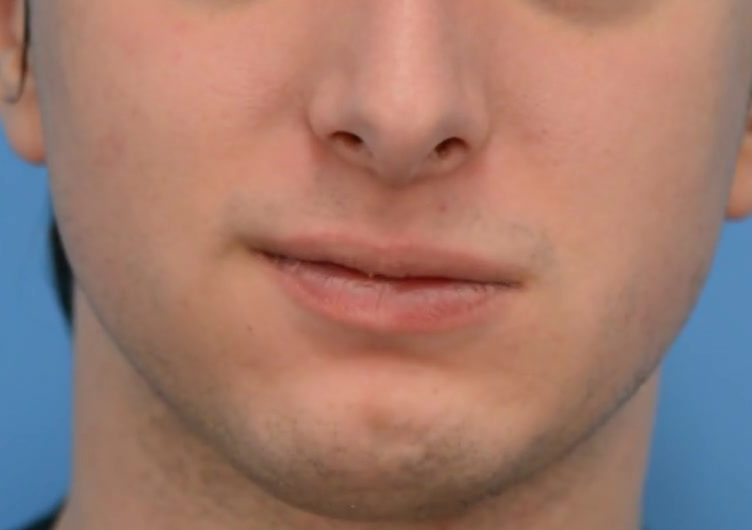

In [ ]:
lower_parts[401]

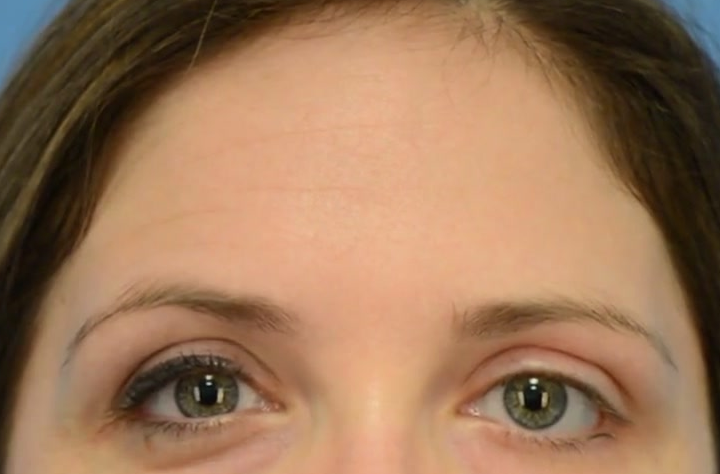

In [ ]:
upper_parts[1]

## before coding

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import glob
import os
from torch.utils.data import WeightedRandomSampler
from google.colab import files
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from collections import defaultdict
from torchvision.datasets import ImageFolder
import random
from collections import Counter
import numpy as np
import csv
from concurrent.futures import as_completed
from PIL import Image
import requests
from io import BytesIO
from PIL import ImageDraw
import pandas as pd

In [ ]:
class FacesDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.data.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:

class faceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_names = sorted(os.listdir(data_dir))  # Get class folder names, sorted for consistency

        # Loop through directories
        for label, class_dir in enumerate(os.listdir(data_dir)):
            class_path = os.path.join(data_dir, class_dir)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    img_path = os.path.join(class_path, img_file)
                    self.image_paths.append(img_path)
                    self.labels.append(label)  # Assign numerical labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")  # Ensure correct format
        if self.transform:
            image = self.transform(image)

        return image, label
    def count_images_per_class(self):
        count_dict = Counter(self.labels)  # self.targets is a list of class indices
        for class_idx, class_name in enumerate(self.class_names):
            count = count_dict.get(class_idx, 0)
            print(f"{class_name}: {count} images")

# Define a wrapper class to apply different transforms
class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]  # Get the image and label
        img = self.transform(img)  # Apply the transform
        return img, label

    def __len__(self):
        return len(self.subset)

In [ ]:
from logging import root
# Load dataset
dataset = Nas(data_dir='/content/drive/MyDrive/final project/dataset/2_classes', transform=None)
print("Classes found:", dataset.class_names)
dataset.count_images_per_class()
print(len(dataset))

Classes found: ['Severe asymmetry', 'normal']
Severe asymmetry: 1112 images
normal: 5522 images
6634


In [ ]:
dataset = NestedImageDataset(root_dir='/content/drive/MyDrive/final project/dataset/6_classes', transform=None)
print("Classes found:", dataset.class_names)
dataset.count_images_per_class()
print(len(dataset))

Classes found: ['CompleteFlaccid', 'MildFlaccid', 'ModerateFlaccid', 'NearNormalFlaccid', 'Normal', 'SevereFlaccid']
CompleteFlaccid: 501 images
MildFlaccid: 80 images
ModerateFlaccid: 542 images
NearNormalFlaccid: 468 images
Normal: 720 images
SevereFlaccid: 514 images
2825


 ## Four‑layer ConvNet to facial emotion recognition with minimal epochs and the significance of data diversity

In [ ]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.7)

        # Dummy forward pass to calculate the correct input size
        self._to_linear = None
        self._get_conv_output((3, 48, 48))

        self.fc1 = nn.Linear(self._to_linear, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, num_classes)
        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(64)

    def _get_conv_output(self, shape):
        """Compute output size of convolutional layers"""
        x = torch.rand(1, *shape)
        x = self.pool(F.relu(self.conv2(F.relu(self.conv1(x)))))
        x = self.pool(F.relu(self.conv4(F.relu(self.conv3(x)))))
        self._to_linear = x.view(1, -1).size(1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x =F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [ ]:
# Define the transformations for both training and testing
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),  # Random Crop
    transforms.RandomHorizontalFlip(p=0.5),  # Flip images randomly
    transforms.RandomRotation(10),  # Rotate images within ±10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Adjust brightness and contrast
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x)  # Ensure exactly 3 channels
])

# For validation/testing — no augmentation, only preprocessing
val_test_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x)
])
dataset_root ='/mnt/drive/MyDrive/final project/dataset/6_classes'
# Load the raw dataset without transform
base_dataset = NestedImageDataset(root_dir=dataset_root, transform=None)

# Split first
total_size = len(base_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.2 * total_size)


train_indices, val_indices = random_split(
    range(total_size), [train_size, val_size]
)

# Apply transforms separately
train_dataset = torch.utils.data.Subset(
    NestedImageDataset(root_dir=dataset_root, transform=train_transform),
    train_indices
)

val_dataset = torch.utils.data.Subset(
    NestedImageDataset(root_dir=dataset_root, transform=val_test_transform),
    val_indices
)


# val and test loaders
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
# Assuming you already have the label list
labels = base_dataset.labels  # list of all labels

# Compute class counts
class_counts = torch.tensor([501, 80, 542, 468, 720,514], dtype=torch.float)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in labels]

# Define sampler
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
# Get indices from the random split
train_indices = train_dataset.indices

# Map original labels to train subset
train_labels = [labels[idx] for idx in train_indices]

# Compute sample weights for train subset only
#sample_weights = [class_weights[label] for label in train_labels]

# Define sampler just for the train set
#sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoader using the sampler
train_loader = DataLoader(train_dataset, batch_size=32, num_workers=0)



In [ ]:
train_labels = [base_dataset.labels[idx] for idx in train_dataset.indices]
Counter(train_labels)


Counter({3: 362, 0: 412, 4: 586, 5: 410, 2: 422, 1: 68})

In [ ]:
print("Testing DataLoader iteration...")
for i, batch in enumerate(train_loader):
    print(f"Batch {i+1} loaded")
    if i == 2:
        break
print("DataLoader is working.")

Testing DataLoader iteration...
Batch 1 loaded
Batch 2 loaded
Batch 3 loaded
DataLoader is working.


In [ ]:
model = EmotionCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

target_accuracy = 98.0  # Stop early if test accuracy reaches this
epochs = 20
best_accuracy = 0.0  # To track best model

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1} starting...")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    class_correct = Counter()
    class_total = Counter()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.long()

        optimizer.zero_grad()
        outputs = model(images)  # ensure model returns only logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for j in range(len(labels)):
            label = labels[j].item()
            pred = predicted[j].item()
            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1

    for cls in sorted(class_correct.keys()):
        acc = 100 * class_correct[cls] / class_total[cls]
        print(f"Class {cls} accuracy: {acc:.2f}%")

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # ---- Validation ----
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_accuracy = 100 * test_correct / test_total
    test_loss /= len(val_loader)
    print(f"Validation Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

    # ---- Save best model ----
    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print("✅ Saved best model")

    # ---- Early stopping ----
    if test_accuracy >= target_accuracy:
        print(f"🎯 Target test accuracy {target_accuracy}% reached. Stopping training.")
        break


Epoch 1 starting...
Class 0 accuracy: 8.93%
Class 2 accuracy: 24.88%
Class 3 accuracy: 6.50%
Class 4 accuracy: 57.31%
Class 5 accuracy: 11.41%
Epoch 1, Train Loss: 1.7879, Train Accuracy: 24.47%
Validation Loss: 1.7810, Test Accuracy: 21.77%
✅ Saved best model

Epoch 2 starting...
Class 0 accuracy: 26.30%
Class 2 accuracy: 24.41%
Class 3 accuracy: 9.21%
Class 4 accuracy: 38.82%
Class 5 accuracy: 26.80%
Epoch 2, Train Loss: 1.7428, Train Accuracy: 25.80%
Validation Loss: 1.7061, Test Accuracy: 35.75%
✅ Saved best model

Epoch 3 starting...
Class 0 accuracy: 32.26%
Class 2 accuracy: 25.12%
Class 3 accuracy: 21.14%
Class 4 accuracy: 23.03%
Class 5 accuracy: 49.13%
Epoch 3, Train Loss: 1.6752, Train Accuracy: 28.76%
Validation Loss: 1.6151, Test Accuracy: 37.88%
✅ Saved best model

Epoch 4 starting...
Class 0 accuracy: 38.71%
Class 2 accuracy: 27.00%
Class 3 accuracy: 44.99%
Class 4 accuracy: 32.27%
Class 5 accuracy: 51.61%
Epoch 4, Train Loss: 1.5882, Train Accuracy: 37.04%
Validation Lo

In [ ]:
!mv best_model.pth /mnt/drive/MyDrive

In [ ]:
import torch.nn.init as init
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            init.zeros_(m.bias)

model.apply(init_weights)

EmotionCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=18432, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (fc3): Linear(in_features=1024, out_features=6, bias=True)
)

In [ ]:
# Assume `model` is your trained PyTorch model
save_path = '/content/drive/MyDrive/final project/my_model.pth'
torch.save(model.state_dict(), save_path)


In [ ]:

# Evaluate the model on test data
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Save the trained model
torch.save(model.state_dict(), 'face_classification_model.pth')


Test Accuracy: 100.00%


In [ ]:
def test_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Test Accuracy: {accuracy:.2f}%")

    return all_preds, all_labels


In [ ]:
all_preds, all_labels = test_model(model, test_loader, device)


✅ Test Accuracy: 99.06%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# Define or initialize your model architecture
model = EmotionCNN().to(device)

# Load weights
model.load_state_dict(torch.load('/content/drive/MyDrive/final project/my_model.pth'))

model.eval()  # Set model to evaluation mode

EmotionCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=18432, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (fc3): Linear(in_features=1024, out_features=6, bias=True)
)

In [ ]:
face_dataset=NestedImageDataset(root_dir='/mnt/drive/MyDrive/final project/dataset/6_classes', transform=val_test_transform)

In [ ]:
# eval the cropped face dataset
face_datalouder = DataLoader(face_dataset, batch_size=16, shuffle=False,num_workers=0)
face_preds, face_labels = test_model(model, face_datalouder, device)

✅ Test Accuracy: 96.46%


In [ ]:
print(classification_report(face_labels, face_preds))
print(confusion_matrix(face_labels, face_preds))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       501
           1       0.50      1.00      0.67        80
           2       1.00      0.95      0.97       542
           3       1.00      0.96      0.98       468
           4       1.00      0.96      0.98       720
           5       0.97      0.98      0.98       514

    accuracy                           0.96      2825
   macro avg       0.91      0.97      0.93      2825
weighted avg       0.98      0.96      0.97      2825

[[485  16   0   0   0   0]
 [  0  80   0   0   0   0]
 [  4  14 514   0   0  10]
 [  0  18   0 450   0   0]
 [  0  24   0   0 690   6]
 [  0   8   0   0   0 506]]


In [ ]:
#sup datalouder
sup_datalouder = DataLoader(sup, batch_size=16, shuffle=False,num_workers=0)
sup_preds, sup_labels = test_model(model, sup_datalouder, device)

✅ Test Accuracy: 16.67%


In [ ]:
print(classification_report(sup_labels, sup_preds))
print(confusion_matrix(sup_labels, sup_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        80
           1       0.00      0.00      0.00        80
           2       0.00      0.00      0.00        80
           3       0.00      0.00      0.00        80
           4       0.00      0.00      0.00        80
           5       0.17      1.00      0.29        80

    accuracy                           0.17       480
   macro avg       0.03      0.17      0.05       480
weighted avg       0.03      0.17      0.05       480

[[ 0  0  0  0  0 80]
 [ 0  0  0  2  0 78]
 [ 0  0  0  0  0 80]
 [ 0  0  0  0  0 80]
 [ 0  0  0  0  0 80]
 [ 0  0  0  0  0 80]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from concurrent.futures import ThreadPoolExecutor
lower_dir= '/content/drive/MyDrive/lower_faces_array'
upper_dir= '/content/drive/MyDrive/upper_faces_array'
lower_images=[]
upper_images=[]
def load_single_image(fname,load_dir):
    img_path = os.path.join(load_dir, fname)
    return img_path

lower_filenames = sorted(os.listdir(lower_dir))  # sorted to preserve order
upper_filenames = sorted(os.listdir(upper_dir))  # sorted to preserve order
for i in range(len(lower_filenames)):

    lower_images.append(load_single_image(lower_filenames[i], lower_dir))
    upper_images.append(load_single_image(upper_filenames[i], upper_dir))


In [ ]:
len(upper_images)

2655

In [ ]:
# Initialize model, loss function, and optimizer
face_model = EmotionCNN().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
# Train the model
epochs = 10
for epoch in range(epochs):
    face_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in face_datalouder:
        images, labels = images.to(device), labels.to(device)
        labels = labels.long()
        optimizer.zero_grad()
        outputs = face_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%")


Epoch 1, Loss: 2.5470, Accuracy: 13.03%
Epoch 2, Loss: 2.5471, Accuracy: 13.71%
Epoch 3, Loss: 2.5473, Accuracy: 14.50%
Epoch 4, Loss: 2.5473, Accuracy: 14.61%
Epoch 5, Loss: 2.5470, Accuracy: 14.84%
Epoch 6, Loss: 2.5475, Accuracy: 14.09%
Epoch 7, Loss: 2.5474, Accuracy: 13.71%
Epoch 8, Loss: 2.5474, Accuracy: 13.82%
Epoch 9, Loss: 2.5477, Accuracy: 13.41%
Epoch 10, Loss: 2.5474, Accuracy: 14.35%


In [ ]:
# eval the cropped lower face dataset
lower_part_dataset = NestedImageDataset(images=lower_images, labels=labels_i, class_names=dataset.class_names, transform=transform)
lower_part_datalouder = DataLoader(lower_part_dataset, batch_size=16, shuffle=False,num_workers=0)
lower_part_preds, lower_part_labels = test_model(model, lower_part_datalouder, device)

✅ Test Accuracy: 20.68%


In [ ]:
# eval the cropped upper face dataset
upper_part_dataset = NestedImageDataset(images=upper_images, labels=labels_i, class_names=dataset.class_names, transform=transform)
upper_part_datalouder = DataLoader(upper_part_dataset, batch_size=16, shuffle=False,num_workers=0)
upper_part_preds, upper_part_labels = test_model(model, upper_part_datalouder, device)

✅ Test Accuracy: 21.69%


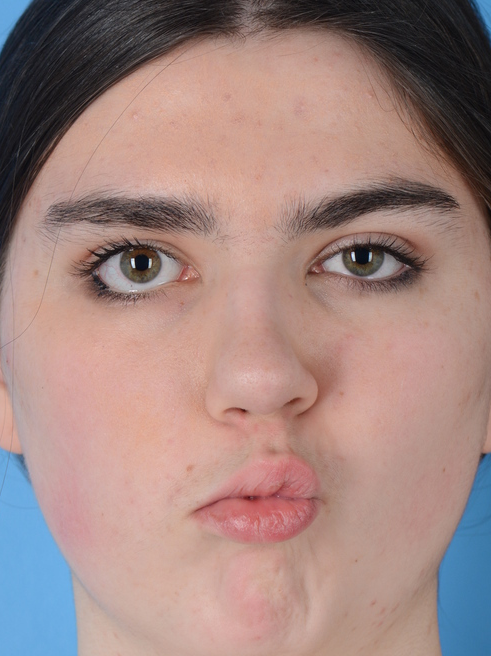

In [ ]:
Image.open(loaded_images[1])

In [ ]:
labels_i[600]

2

##  Visual Facial Paralysis Detection using InceptionResNetV2



In [ ]:
# Define the Inception-ResNet CNN Model
class InceptionResNetModel(nn.Module):
    def __init__(self, num_classes=6):
        super(InceptionResNetModel, self).__init__()

        # Initial convolutional layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(3, stride=2)
        self.conv4 = nn.Conv2d(64, 80, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(80, 192, kernel_size=3, stride=2, padding=0)

        #Inception-ResNet A modules
        self.inception_resnet_a = self._inception_resnet_stack(192, 320, 5)
        self.reduction_a = nn.Conv2d(320, 256, kernel_size=3, stride=2, padding=1)
        self.pool1 = nn.MaxPool2d(3, stride=2)
        # Inception-ResNet B modules
        self.inception_resnet_b = self._inception_resnet_stack(256, 1088, 10)
        self.reduction_b = nn.Conv2d(1088, 288, kernel_size=3, stride=2, padding=1)

        # Inception-ResNet C modules
        self.inception_resnet_c = self._inception_resnet_stack(288, 1536, 5)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Dense Blocks
        self.fc1 = nn.Linear(1536, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, num_classes)  # three-class output (Stroke Face, Normal Face)

    def _inception_resnet_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
    def _inception_resnet_stack(self, in_channels, out_channels, num_blocks):
        layers = []
        for _ in range(num_blocks):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            in_channels = out_channels
        return nn.Sequential(*layers)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool1(x)
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.inception_resnet_a(x)
        x = self.reduction_a(x)
        x = self.inception_resnet_b(x)
        x = self.reduction_b(x)
        x = self.inception_resnet_c(x)
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Hyperparameters
epochs = 10

transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Ensure 3 channels
    transforms.RandomHorizontalFlip(),         # flips images with 50% chance
    transforms.RandomRotation(15),             # rotate ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Match 3 channels
])



In [ ]:
dataset_root ='/content/drive/MyDrive/final project/dataset/6_classes'


# dataset is already loaded
dataset = NestedImageDataset(root_dir=dataset_root, transform=transform)

total_size = len(dataset)
train_size = int(0.7 * total_size)   # 70% for training
val_size = int(0.15 * total_size)    # 15% for validation
test_size = total_size - train_size - val_size  # 15% for testing

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# val and test loaders
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
# Assuming you already have the label list
labels = dataset.labels  # list of all labels

# Compute class counts
class_counts = torch.tensor([501, 80, 542, 468, 514, 550], dtype=torch.float)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in labels]

# Define sampler
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
# Get indices from the random split
train_indices = train_dataset.indices

# Map original labels to train subset
train_labels = [labels[idx] for idx in train_indices]

# Compute sample weights for train subset only
sample_weights = [class_weights[label] for label in train_labels]

# Define sampler just for the train set
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoader using the sampler
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=0)


In [ ]:
model = InceptionResNetModel()
print(model)

InceptionResNetModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(80, 192, kernel_size=(3, 3), stride=(2, 2))
  (inception_resnet_a): Sequential(
    (0): Conv2d(192, 320, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(320, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
    (4): BatchNorm2d(320, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
    (7): BatchNorm2d(320, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(32

In [ ]:
import torch.optim as optim

model = InceptionResNetModel().to(device)
dummy_input = torch.randn(1, 3, 224, 224).to(device)
output = model(dummy_input)
print("Output shape:", output.shape)


Output shape: torch.Size([1, 3])


In [ ]:
# Initialize model, loss function, and optimizer
model = InceptionResNetModel().to(device)

normalized_weights = class_weights / class_weights.max()

criterion = nn.CrossEntropyLoss(weight=normalized_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
# Train the model
epochs = 25
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    class_correct = Counter()
    class_total = Counter()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.long()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)):
            label = labels[i].item()
            pred = predicted[i].item()
            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1

    # Print per-class accuracy **after the epoch**
    for cls in sorted(class_correct.keys()):
        acc = 100 * class_correct[cls] / class_total[cls]
        print(f"Class {cls} accuracy: {acc:.2f}%")

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%")


In [ ]:
# Evaluate the model on test data
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Save the trained model
torch.save(model.state_dict(), 'face_classification_model.pth')


Test Accuracy: 60.31%


##  Facial expression recognition via deep learning


In [ ]:
import torch
import torch.nn as nn

class ExpressionCNN(nn.Module):
    def __init__(self, num_classes=6):  # make sure num_classes matches your dataset!
        super(ExpressionCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=20, kernel_size=4, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=40, kernel_size=3, stride=2, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(in_channels=40, out_channels=60, kernel_size=3, stride=2, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=1)
        self.conv4 = nn.Conv2d(in_channels=60, out_channels=80, kernel_size=2, stride=2, padding=0)

        # Global Average Pooling (makes sure output is (batch, 80, 1, 1))
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected layers
        self.fc1 = nn.Linear(80, 160)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(160, num_classes)
        self.bn1 = nn.BatchNorm2d(20)
        self.bn2 = nn.BatchNorm2d(40)
        self.bn3 = nn.BatchNorm2d(60)
        self.bn4 = nn.BatchNorm2d(80)

    def forward(self, x):

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = F.relu(self.bn4(self.conv4(x)))

        x = self.global_avg_pool(x)  # (batch, 80, 1, 1)
        x = torch.flatten(x, 1)      # (batch, 80)

        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((165, 165)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.02),
    transforms.GaussianBlur(kernel_size=5),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + 0.03 * torch.randn_like(x)),  # Add noise
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
])
# For validation/testing — no augmentation, only preprocessing
val_test_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x)
])


dataset_root ='/mnt/drive/MyDrive/final project/dataset/6_classes'

dataset = NestedImageDataset(root_dir=dataset_root, transform=None)

total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_indices,  test_indices = random_split(
    range(total_size), [train_size, val_size]
)

# Apply transforms separately
train_dataset = torch.utils.data.Subset(
    NestedImageDataset(root_dir=dataset_root, transform=train_transform),
    train_indices
)

val_dataset = torch.utils.data.Subset(
    NestedImageDataset(root_dir=dataset_root, transform=val_test_transform),
    test_indices
)
# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,num_workers=4)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,num_workers=4)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# Train the model
epochs = 25
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    class_correct = Counter()
    class_total = Counter()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.long()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)):
            label = labels[i].item()
            pred = predicted[i].item()
            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1

    # Print per-class accuracy **after the epoch**
    for cls in sorted(class_correct.keys()):
        acc = 100 * class_correct[cls] / class_total[cls]
        print(f"Class {cls} accuracy: {acc:.2f}%")

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%")


Class 0 accuracy: 73.21%
Class 1 accuracy: 8.47%
Class 2 accuracy: 67.76%
Class 3 accuracy: 70.57%
Class 4 accuracy: 81.34%
Class 5 accuracy: 77.14%
Epoch 1, Loss: 0.7250, Accuracy: 72.83%
Class 0 accuracy: 73.68%
Class 1 accuracy: 10.17%
Class 2 accuracy: 74.53%
Class 3 accuracy: 77.66%
Class 4 accuracy: 83.98%
Class 5 accuracy: 76.43%
Epoch 2, Loss: 0.6859, Accuracy: 75.93%
Class 0 accuracy: 73.68%
Class 1 accuracy: 8.47%
Class 2 accuracy: 71.50%
Class 3 accuracy: 74.39%
Class 4 accuracy: 82.39%
Class 5 accuracy: 77.38%
Epoch 3, Loss: 0.7111, Accuracy: 74.56%
Class 0 accuracy: 81.10%
Class 1 accuracy: 5.08%
Class 2 accuracy: 73.36%
Class 3 accuracy: 75.20%
Class 4 accuracy: 79.05%
Class 5 accuracy: 77.14%
Epoch 4, Loss: 0.6670, Accuracy: 75.44%
Class 0 accuracy: 77.75%
Class 1 accuracy: 11.86%
Class 2 accuracy: 71.96%
Class 3 accuracy: 78.47%
Class 4 accuracy: 85.74%
Class 5 accuracy: 80.48%
Epoch 5, Loss: 0.6497, Accuracy: 77.57%
Class 0 accuracy: 73.68%
Class 1 accuracy: 6.78%
Clas

In [ ]:
# Recreate the model and optimizer objects
model = ExpressionCNN()  # Replace with your actual model class
optimizer = torch.optim.Adam(model.parameters())  # Or whatever optimizer you used

# Load the checkpoint
checkpoint = torch.load('/content/drive/MyDrive/final project/checkpoint.pth')

# Restore the model and optimizer state
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Optional: restore epoch
start_epoch = checkpoint['epoch']


In [ ]:
labels

tensor([4, 4, 4, 2, 0, 0, 2, 4, 0, 4, 4], device='cuda:0')

##  Facial Palsy Detection Through Changes In Facial Muscle Functionality Using CNN Algorithm

In [ ]:
# Define the CNN model
class FacialPalsyCNN(nn.Module):
    def __init__(self):
        super(FacialPalsyCNN, self).__init__()

        # First convolutional layer: 6 filters, 5x5 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # MaxPooling 2x2

        # Second convolutional layer: 16 filters, 5x5 kernel
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2)

        # Flatten layer
        self.flatten = nn.Flatten()

        # Fully connected layers
        self.fc1 = nn.Linear(16 * 56 * 56, 128)  # Adjusting based on feature map size
        self.fc2 = nn.Linear(128, 6)  # 6 classes

        # Output activation (Softmax for multi-class classification)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # Conv1 -> ReLU -> MaxPool
        x = self.pool(self.relu(self.conv2(x)))  # Conv2 -> ReLU -> MaxPool
        x = self.flatten(x)  # Flatten feature map
        x = self.relu(self.fc1(x))  # Fully connected layer 1
        x = self.fc2(x)  # Fully connected layer 2 (logits)
        return self.softmax(x)  # Apply softmax to get class probabilities



In [ ]:
import numpy as np
from sklearn.model_selection import KFold
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),        # Random crop + resize
    transforms.RandomHorizontalFlip(p=0.5),                           # Random horizontal flip
    transforms.RandomRotation(degrees=15),                            # Random small rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),             # Slight brightness/contrast jitter (note: less effect on grayscale)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),         # Random small translations
    transforms.Grayscale(num_output_channels=1),                      # Convert to grayscale
    transforms.ToTensor(),                                            # Convert PIL image to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])                       # Normalize grayscale
])
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
# Track fold results
fold_results = {}
dataset= NestedImageDataset(root_dir='/content/drive/MyDrive/final project/dataset/6_classes', transform=train_transform)
dataset_size = len(dataset)
indices = list(range(dataset_size))


In [ ]:
for fold, (train_idx, val_idx) in enumerate(kfold.split(indices)):
    print(f'--- Fold {fold + 1}/{k_folds} ---')

    # Create dataloaders for this fold
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=0)

        # Initialize model, loss, optimizer
    model = FacialPalsyCNN().to(device)  # Move model to device
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs=10
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {train_accuracy:.2f}%')

    # Evaluate on validation set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(f'Fold {fold+1} Validation Accuracy: {val_accuracy:.2f}%')

    # Save result
    fold_results[fold] = val_accuracy

# Final summary
print('\n--- K-Fold Cross-Validation Results ---')
for fold, acc in fold_results.items():
    print(f'Fold {fold+1}: {acc:.2f}%')
print(f'Average Accuracy: {np.mean(list(fold_results.values())):.2f}%')

--- Fold 1/5 ---
Epoch 1: Loss = 1.8388, Accuracy = 20.29%
Epoch 2: Loss = 1.8407, Accuracy = 20.29%
Epoch 3: Loss = 1.8419, Accuracy = 20.15%
Epoch 4: Loss = 1.8442, Accuracy = 19.96%
Epoch 5: Loss = 1.8440, Accuracy = 19.96%
Epoch 6: Loss = 1.8442, Accuracy = 19.96%
Epoch 7: Loss = 1.8434, Accuracy = 19.96%
Epoch 8: Loss = 1.8437, Accuracy = 19.96%
Epoch 9: Loss = 1.8442, Accuracy = 19.96%
Epoch 10: Loss = 1.8439, Accuracy = 19.96%
Fold 1 Validation Accuracy: 16.95%
--- Fold 2/5 ---
Epoch 1: Loss = 1.6316, Accuracy = 40.35%
Epoch 2: Loss = 1.5441, Accuracy = 48.78%
Epoch 3: Loss = 1.4654, Accuracy = 57.67%
Epoch 4: Loss = 1.4478, Accuracy = 59.42%
Epoch 5: Loss = 1.4174, Accuracy = 62.19%
Epoch 6: Loss = 1.4026, Accuracy = 63.65%
Epoch 7: Loss = 1.3664, Accuracy = 67.28%
Epoch 8: Loss = 1.3373, Accuracy = 70.67%
Epoch 9: Loss = 1.3358, Accuracy = 71.05%
Epoch 10: Loss = 1.3111, Accuracy = 72.69%
Fold 2 Validation Accuracy: 74.20%
--- Fold 3/5 ---
Epoch 1: Loss = 1.6352, Accuracy = 38

In [ ]:
# Define the transformations for both training and testing

train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),        # Random crop + resize
    transforms.RandomHorizontalFlip(p=0.5),                           # Random horizontal flip
    transforms.RandomRotation(degrees=15),                            # Random small rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),             # Slight brightness/contrast jitter (note: less effect on grayscale)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),         # Random small translations
    transforms.Grayscale(num_output_channels=1),                      # Convert to grayscale
    transforms.ToTensor(),                                            # Convert PIL image to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])                       # Normalize grayscale
])
# **Ensure the same split every time**
dataset= faceDataset(data_dir='/content/drive/MyDrive/final project/dataset/2_classes', transform=train_transform)
torch.manual_seed(42)  # Set seed for reproducibility
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])


# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
from tqdm import tqdm
model = FacialPalsyCNN().to(device)  # Move model to device
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    model.train()
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        labels = labels.long()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {train_accuracy:.2f}%")

# After training, evaluate on test data
model.eval()  # Set model to evaluation mode
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Epoch 1/10: 100%|██████████| 332/332 [06:54<00:00,  1.25s/it]


Epoch 1, Loss: 0.4799, Accuracy: 83.21%


Epoch 2/10: 100%|██████████| 332/332 [00:43<00:00,  7.63it/s]


Epoch 2, Loss: 0.4788, Accuracy: 83.47%


Epoch 3/10: 100%|██████████| 332/332 [00:43<00:00,  7.70it/s]


...

Epoch 8, Loss: 0.4784, Accuracy: 83.47%


Epoch 9/10: 100%|██████████| 332/332 [00:43<00:00,  7.56it/s]


Epoch 9, Loss: 0.4785, Accuracy: 83.47%


Epoch 10/10: 100%|██████████| 332/332 [00:43<00:00,  7.66it/s]


Epoch 10, Loss: 0.4788, Accuracy: 83.47%
Test Accuracy: 82.29%
